# Timeline plots: full network by era + main-storyline subgraph

Two visualizations:

1. **Full character network coloured by era** — see whether the temporal information aligns with the network structure. Edges between characters from the same era are highlighted; cross-era edges are drawn very faintly.
2. **Main storyline only** — sub-network restricted to characters with `era == 'ASOIAF main'`. Coloured by region. This is the cleanest view of the *current-timeline* social graph without the dynastic smear of Fire & Blood / Targaryen Conquest characters.

**Dependencies:**
- `../characters_enriched_v3.csv` — produced by `../scrape_characters_v3.ipynb` (the include-list scraper, History + Recent Events only)
- `eras.csv` — produced by `03_execute.ipynb` in this folder
- `../community_vs_region.csv` — for region coloring on plot 2

In [11]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter

df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
eras = pd.read_csv('eras.csv').fillna('')
region_df = pd.read_csv('../csvs/community_vs_region.csv').fillna('')

era_by_id = dict(zip(eras['ID'], eras['era']))
book_by_id = dict(zip(eras['ID'], eras['book_bucket'])) if 'book_bucket' in eras.columns else {}
region_by_id = dict(zip(region_df['ID'], region_df['region']))
name_by_id = dict(zip(df['ID'], df['name']))

print(f'v3 characters:   {len(df):,}')
print(f'Era assignments: {len(eras):,}')


v3 characters:   3,690
Era assignments: 3,690


### Build the v3 network
Same construction as the main project: undirected edge `A↔B` if either endpoint lists the other in its `affiliated` column. We use the v3 column going forward — narrative prose only, no navbox / succession / infobox leakage.

In [12]:
edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in name_by_id:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
era_node = {n: era_by_id.get(n, 'Unknown') for n in LCC.nodes()}
book_node = {n: book_by_id.get(n, 'Unknown') for n in LCC.nodes()}

era_counts = Counter(era_node.values())
print(f'Full graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'LCC:        {LCC.number_of_nodes():,} nodes, {LCC.number_of_edges():,} edges\n')
print('Era distribution in LCC:')
for e, n in sorted(era_counts.items(), key=lambda x: -x[1]):
    print(f'  {e:25s} {n:>5d}')


Full graph: 3,690 nodes, 17,169 edges
LCC:        3,046 nodes, 17,057 edges

Era distribution in LCC:
  Unknown                    1494
  ASOIAF main                 522
  Fire & Blood                504
  Mid-Targaryen               127
  Late Targaryen              120
  Robert's Reign              118
  Targaryen Conquest          110
  Pre-Conquest                 51


### Same-era edge fraction
Pre-flight sanity check: how often do connected character pairs share an era? If the era assignment is informative, this should be much higher than chance.

In [13]:
total = LCC.number_of_edges()
both_era = sum(1 for u, v in LCC.edges()
               if era_node[u] != 'Unknown' and era_node[v] != 'Unknown')
same_era = sum(1 for u, v in LCC.edges()
               if era_node[u] == era_node[v] and era_node[u] != 'Unknown')
both_book = sum(1 for u, v in LCC.edges()
                if book_node[u] != 'Unknown' and book_node[v] != 'Unknown')
same_book = sum(1 for u, v in LCC.edges()
                if book_node[u] == book_node[v] and book_node[u] != 'Unknown')

print(f'Total LCC edges:                            {total:,}')
print(f'7-era view:')
print(f'  Both endpoints have known era:            {both_era:,}  ({both_era/total:.1%})')
print(f'  Same-era edges (excluding Unknown):       {same_era:,}  ({same_era/max(both_era,1):.1%} of known)')
print(f'3-bucket view:')
print(f'  Both endpoints have known book bucket:    {both_book:,}  ({both_book/total:.1%})')
print(f'  Same-bucket edges (excluding Unknown):    {same_book:,}  ({same_book/max(both_book,1):.1%} of known)')


Total LCC edges:                            17,057
7-era view:
  Both endpoints have known era:            8,811  (51.7%)
  Same-era edges (excluding Unknown):       5,772  (65.5% of known)
3-bucket view:
  Both endpoints have known book bucket:    0  (0.0%)
  Same-bucket edges (excluding Unknown):    0  (0.0% of known)


## Plot 1: Full network coloured by **book bucket**

The earlier 7-era version of this plot showed that the v3 network separates into two visual clusters that correspond not to fine-grained eras but to **publication series** — *Fire & Blood* characters form their own cluster, the rest mix together regardless of in-universe generation. We collapse the eras into 3 book buckets to match what the network is actually showing:

- **Fire & Blood** (years < 200 AC) — pre-Conquest, Conquest, and F&B proper
- **Tales of Dunk & Egg** (200–250 AC) — Hedge Knight novella era
- **A Song of Ice and Fire** (250–310 AC) — main series plus the immediate prior generation (Aerys II, Tywin's youth, Rhaegar, Robert's Rebellion)
- **Unknown** — characters with no inferable date

Cross-bucket edges are drawn very faintly so the within-bucket structure dominates.

Book-bucket distribution in LCC:
  Fire & Blood                  0
  Tales of Dunk & Egg           0
  A Song of Ice and Fire        0
  Unknown                    3046


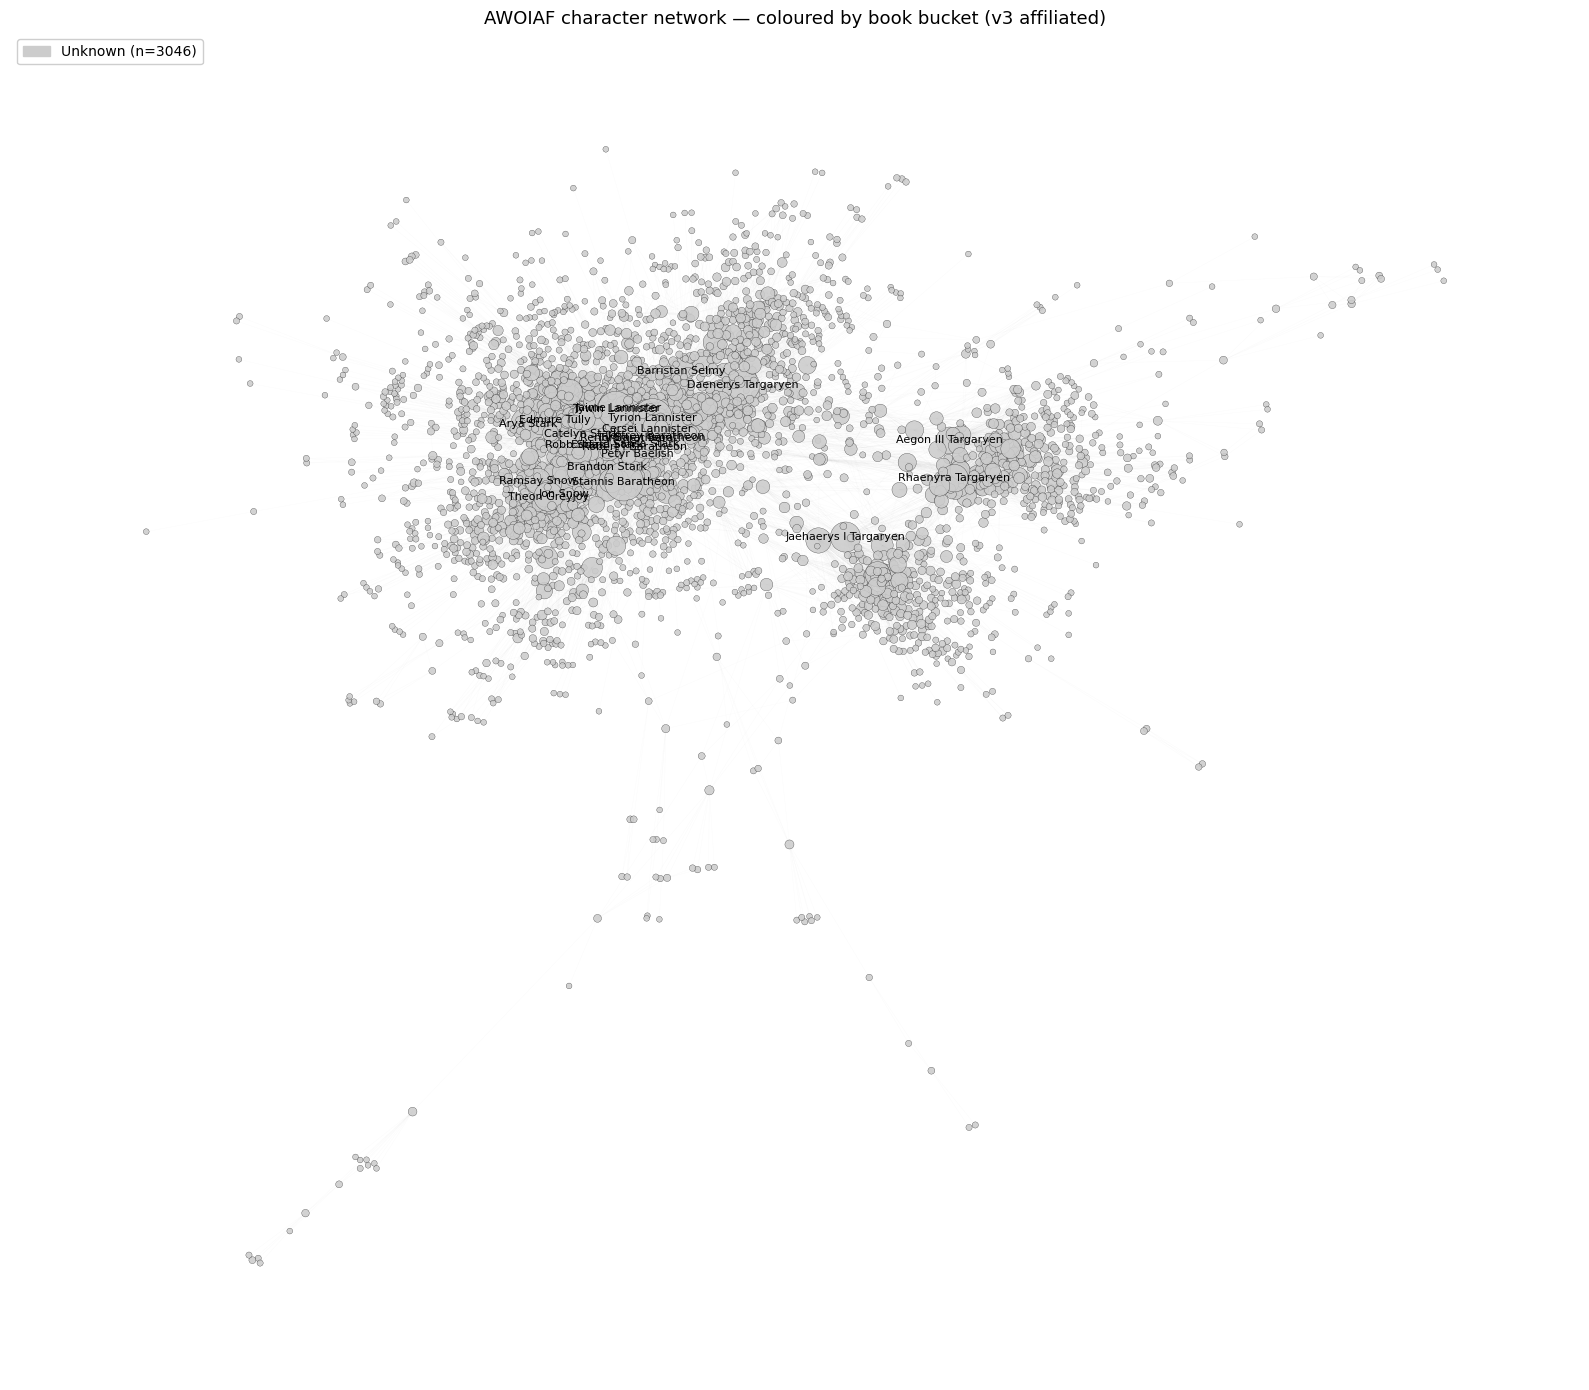

In [14]:
BOOK_ORDER = ['Fire & Blood', 'Tales of Dunk & Egg', 'A Song of Ice and Fire', 'Unknown']
BOOK_COLOR = {
    'Fire & Blood':            '#ff6600',
    'Tales of Dunk & Egg':     '#9b6bb0',
    'A Song of Ice and Fire':  '#a83232',
    'Unknown':                 '#cccccc',
}

book_counts = Counter(book_node.values())
print('Book-bucket distribution in LCC:')
for b in BOOK_ORDER:
    print(f'  {b:25s} {book_counts.get(b, 0):>5d}')

pos = nx.spring_layout(LCC, k=0.25, seed=42, iterations=200)

same_edges_by_bucket = {b: [] for b in BOOK_ORDER}
cross_edges = []
for u, v in LCC.edges():
    bu, bv = book_node[u], book_node[v]
    if bu == bv and bu != 'Unknown':
        same_edges_by_bucket[bu].append((u, v))
    else:
        cross_edges.append((u, v))

fig, ax = plt.subplots(figsize=(16, 14))
nx.draw_networkx_edges(LCC, pos, edgelist=cross_edges,
                       edge_color='grey', alpha=0.04, width=0.3, ax=ax)
for b in BOOK_ORDER:
    if not same_edges_by_bucket[b]:
        continue
    nx.draw_networkx_edges(LCC, pos, edgelist=same_edges_by_bucket[b],
                           edge_color=BOOK_COLOR[b], alpha=0.4, width=0.6, ax=ax)

node_colors = [BOOK_COLOR[book_node[n]] for n in LCC.nodes()]
node_sizes = [15 + LCC.degree(n) * 2.5 for n in LCC.nodes()]
nx.draw_networkx_nodes(LCC, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.88, linewidths=0.2, edgecolors='black', ax=ax)

top = sorted(LCC.nodes(), key=lambda n: LCC.degree(n), reverse=True)[:25]
nx.draw_networkx_labels(LCC, pos,
                        labels={n: name_by_id.get(n, n) for n in top},
                        font_size=8, ax=ax)

handles = [mpatches.Patch(color=BOOK_COLOR[b], label=f'{b} (n={book_counts.get(b, 0)})')
           for b in BOOK_ORDER if book_counts.get(b, 0) > 0]
ax.legend(handles=handles, loc='upper left', fontsize=10, framealpha=0.95)
ax.set_title('AWOIAF character network — coloured by book bucket (v3 affiliated)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Plot 2: Main storyline only

Sub-graph induced by characters with `era == 'ASOIAF main'` (≈ 298–305 AC). We re-run the spring layout on this filtered graph — without the temporal-smear pull from Fire & Blood ancestors, the community structure should be much cleaner.

Coloured by Westerosi region. The expectation is that region clusters become more visually obvious than in the smeared full graph.

Main storyline subgraph: 522 nodes, 2,035 edges
Main storyline LCC:      463 nodes, 2,028 edges
Components in subgraph:  53


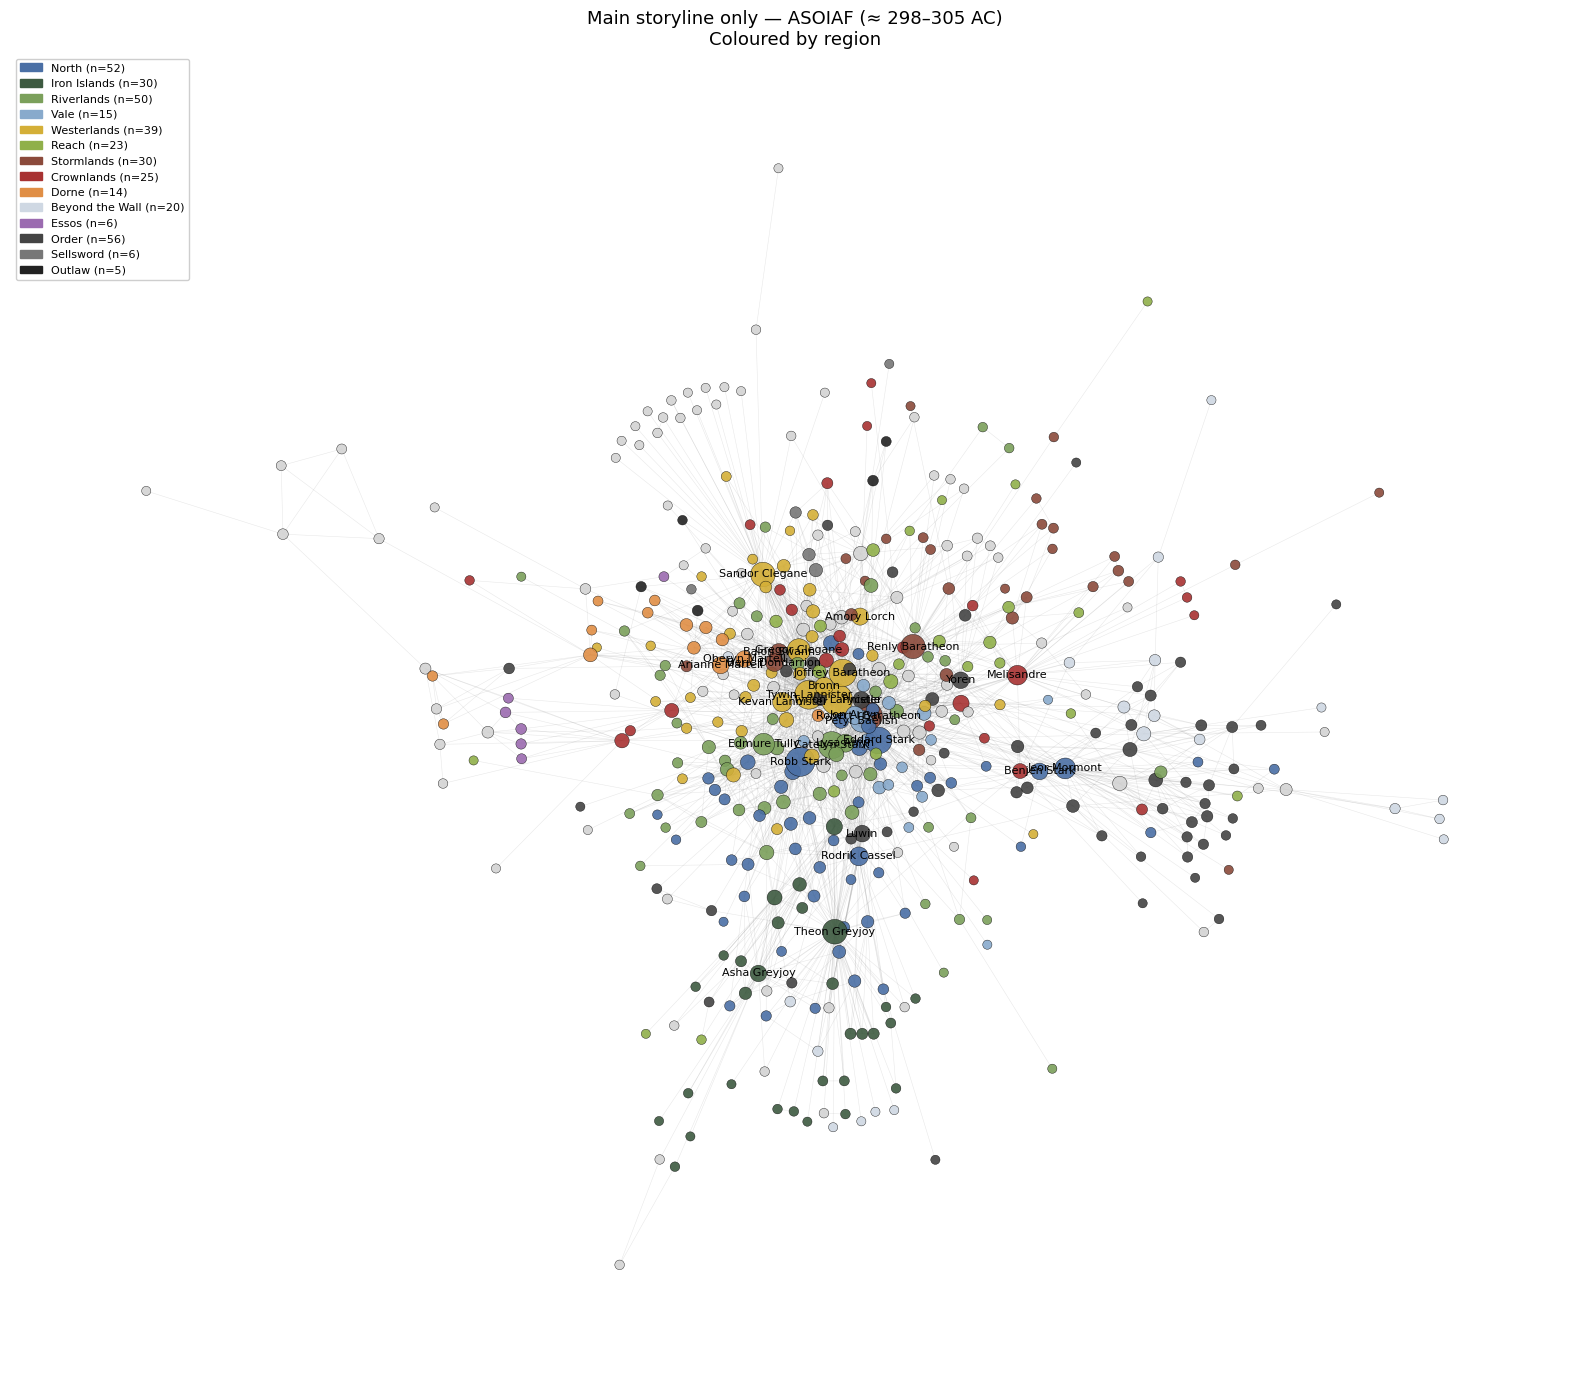

In [15]:
REGION_COLOR = {
    'North':           '#4a6fa5',
    'Iron_Islands':    '#3d5a40',
    'Riverlands':      '#7ba05b',
    'Vale':            '#88aacc',
    'Westerlands':     '#d4af37',
    'Reach':           '#90b04a',
    'Stormlands':      '#8b4a3b',
    'Crownlands':      '#a83232',
    'Dorne':           '#e08e45',
    'Beyond_the_Wall': '#cfd8e3',
    'Essos':           '#9b6bb0',
    'Order':           '#444444',
    'Sellsword':       '#777777',
    'Outlaw':          '#222222',
}

main_nodes = [n for n in LCC.nodes() if era_node[n] == 'ASOIAF main']
main_sub = LCC.subgraph(main_nodes).copy()
if main_sub.number_of_edges() == 0:
    print('No main-storyline edges found. Re-run 03_execute.ipynb first.')
else:
    components = list(nx.connected_components(main_sub))
    main_lcc = main_sub.subgraph(max(components, key=len)).copy()
    print(f'Main storyline subgraph: {main_sub.number_of_nodes():,} nodes, {main_sub.number_of_edges():,} edges')
    print(f'Main storyline LCC:      {main_lcc.number_of_nodes():,} nodes, {main_lcc.number_of_edges():,} edges')
    print(f'Components in subgraph:  {len(components)}')

    pos2 = nx.spring_layout(main_lcc, k=0.35, seed=42, iterations=200)
    node_colors2 = [REGION_COLOR.get(region_by_id.get(n, ''), 'lightgrey') for n in main_lcc.nodes()]
    node_sizes2 = [40 + main_lcc.degree(n) * 4 for n in main_lcc.nodes()]

    fig, ax = plt.subplots(figsize=(16, 14))
    nx.draw_networkx_edges(main_lcc, pos2, edge_color='grey', alpha=0.18, width=0.4, ax=ax)
    nx.draw_networkx_nodes(main_lcc, pos2, node_color=node_colors2, node_size=node_sizes2,
                           alpha=0.9, linewidths=0.3, edgecolors='black', ax=ax)

    top2 = sorted(main_lcc.nodes(), key=lambda n: main_lcc.degree(n), reverse=True)[:30]
    nx.draw_networkx_labels(main_lcc, pos2,
                            labels={n: name_by_id.get(n, n) for n in top2},
                            font_size=8, ax=ax)

    region_present = Counter(region_by_id.get(n, '') for n in main_lcc.nodes())
    handles2 = [mpatches.Patch(color=c, label=f"{r.replace('_', ' ')} (n={region_present[r]})")
                for r, c in REGION_COLOR.items() if region_present[r] > 0]
    ax.legend(handles=handles2, loc='upper left', fontsize=8, framealpha=0.95)
    ax.set_title('Main storyline only — ASOIAF (≈ 298–305 AC)\nColoured by region', fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


## Interpretation

Two things to look for in the main-storyline plot:

1. **Region clusters should pop.** With Fire & Blood ancestors removed, the Crownlands cluster is no longer dominated by ancient Targaryens — it should reduce to King's Landing courtiers + the contemporary Targaryen restoration network (Daenerys + entourage in Essos may still be there because of Recent Events references in mainline-character pages).
2. **Cross-region bridges become legible.** Edges like Sansa Stark → Tyrion Lannister (Lannister-Stark marriage) or Jon Snow → Sam Tarly (Reach to Wall) are the kind of plot-driven bridges that get drowned by genealogical edges in the full graph. Here they should be visible.

If neither pattern shows, the most likely culprit is sparse era assignment — many ASOIAF-main characters got `Unknown` because `03_execute.ipynb` couldn't find a year. The fix is then upstream: get better coverage from `Born` / `Died` or the book-mention fallback in the cascade.

**Stretch goal:** re-run Louvain on `main_lcc` and compare modularity + region purity to the full-LCC v3 baseline. If both improve, that's quantitative evidence that the temporal smear was systematically hurting the v2/v3 community detection.